#Notebook to take CSV files of PC3 treated cells at 5 and 10 DPT with cisplatin/docetaxel to induce PACCs and create classifiers for PACCs. Benchmark on MDA PACCs cellines.

In [1]:
#Load pandas, numpy, scikit for ML classifiers
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import seaborn as sns
import matplotlib.pyplot as plt

######Section 1:Training PC3-treated cisplatin cell PACCs classifiers


In [3]:


#Read in training data for PC3 cells treated with cisplatin for 10 and 5 days and untreated cells - 1000 downsampled cells for each condition from overall experiment
pc3_c_df = pd.read_csv("/Users/debanjansaha/Desktop/mCRPC_analysis/R/pc3_analysis/copykatres_pc3_c_meta.csv")  # must contain numeric features and 'label' column

# Encode labels - 10DPT and 5DPT treated as PACCs with indicator with PC3(untreated) cells labeled as 0
pc3_c_df['label'] = pc3_c_df['Notation'].map({'c10': 1, 'c5': 1, 'PC3': 0})  # binary encoding

#Extract features and labels - final features are the following for PACCs classification: CNV_total, nUMI, nFeatures, G2M.score, S.score, Hallmark pathways module scores
pc3_c_X = pc3_c_df.drop(columns=['label', 'Unnamed: 0', 'cell', 'Notation'])



feature_cols = [
        "Percent.MT","S.Score","cnv_total",
        "nCount_RNA","nFeature_RNA",
        "G2M.Score"
]

"""
"HALLMARK_APOPTOSIS7","HALLMARK_COAGULATION10",
        "HALLMARK_COMPLEMENT11","HALLMARK_IL2_STAT5_SIGNALING23",
        "HALLMARK_INFLAMMATORY_RESPONSE25",
        "HALLMARK_INTERFERON_ALPHA_RESPONSE26",
        "HALLMARK_INTERFERON_GAMMA_RESPONSE27",
        "HALLMARK_TNFA_SIGNALING_VIA_NFKB45"
    ]
"""
pc3_c_X = pc3_c_X[feature_cols]

#Indicator for PACCs
pc3_c_y = pc3_c_df['label']




In [4]:
#Models to evaluate
models = {
    "LogisticRegression": LogisticRegression(penalty='l1', solver='saga', C=0.1),
    "RandomForest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
    "SVM": SVC(probability=True, kernel='rbf', C=1),  # RBF kernel, enable proba
    "NeuralNet": MLPClassifier(hidden_layer_sizes=(50, 20), max_iter=500)
}
# Cross-validation setup
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {name: [] for name in models}

from sklearn.preprocessing import StandardScaler

#5 fold cross-validation with test/train split, scaling on training and test data, and model fitting with assessment on hold test data for each fold
for name, model in models.items():
    for train_idx, test_idx in StratifiedKFold(n_splits=5, shuffle=True, random_state=123).split(pc3_c_X, pc3_c_y):
        X_train, X_test = pc3_c_X.iloc[train_idx], pc3_c_X.iloc[test_idx]
        y_train, y_test = pc3_c_y.iloc[train_idx], pc3_c_y.iloc[test_idx]

        # Scale within the fold
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model.fit(X_train_scaled, y_train)
        probs = model.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, probs)
        cv_results[name].append(auc)




/opt/anaconda3/envs/ds/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [04:21:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/ds/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [04:21:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/ds/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [04:21:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/ds/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [04:21:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.



In [5]:
#Store results as df
k_fold_res = pd.DataFrame(cv_results)

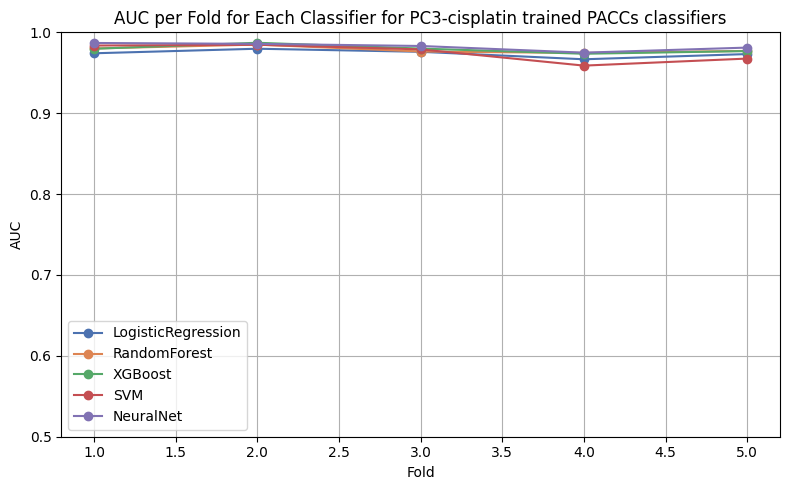

In [6]:
# Choose a seaborn palette (examples: "Set1", "Set2", "colorblind", "tab10", "deep", etc.)
palette = sns.color_palette("deep", n_colors=len(k_fold_res.columns))

plt.figure(figsize=(8, 5))

# Assign each model a color from the palette
for i, model in enumerate(k_fold_res.columns):
    plt.plot(k_fold_res.index + 1, 
             k_fold_res[model], 
             marker='o', 
             label=model, 
             color=palette[i])

plt.xlabel("Fold")
plt.ylabel("AUC")
plt.title("AUC per Fold for Each Classifier for PC3-cisplatin trained PACCs classifiers")
plt.ylim(0.5, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save as PDF
plt.savefig("/Users/debanjansaha/Desktop/pca_c_class_train.pdf")


In [7]:
#Write to TSV for plotting
k_fold_res.to_csv("/Users/debanjansaha/Desktop/pca_c_class_train_results.tsv", sep="\t", index=False)

In [8]:
#Get feature names
features = pc3_c_X.columns

#Get coefficients for LogReg and feature importances for RF and XGBoost
logreg_coefs = np.abs(models["LogisticRegression"].coef_[0])
rf_coefs = models["RandomForest"].feature_importances_
xgboost_coefs = models["XGBoost"].feature_importances_

#Use 1 fold training to get feature importance for SVM and NN
from sklearn.inspection import permutation_importance
svm = SVC(probability=True, kernel='rbf', C=1)
svm.fit(X_train_scaled, y_train)
svm_feature_import = permutation_importance(svm, X_test_scaled, y_test, n_repeats=10, random_state=123)

mlp = MLPClassifier(hidden_layer_sizes=(50, 20), max_iter=500)
mlp.fit(X_train_scaled, y_train)
nn_feature_import = permutation_importance(mlp, X_test_scaled, y_test, n_repeats=10, random_state=42)
nn_feature_import = np.abs(nn_feature_import.importances_mean)  # take absolute value

#Cbind all feature importances and normalize to max value per column
importance_df = pd.DataFrame({"LR": logreg_coefs, "RF": rf_coefs, "XGB": xgboost_coefs, "SVM":svm_feature_import.importances_mean, "NN":nn_feature_import}, index = features)
normalized_df = importance_df / importance_df.max()



/opt/anaconda3/envs/ds/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


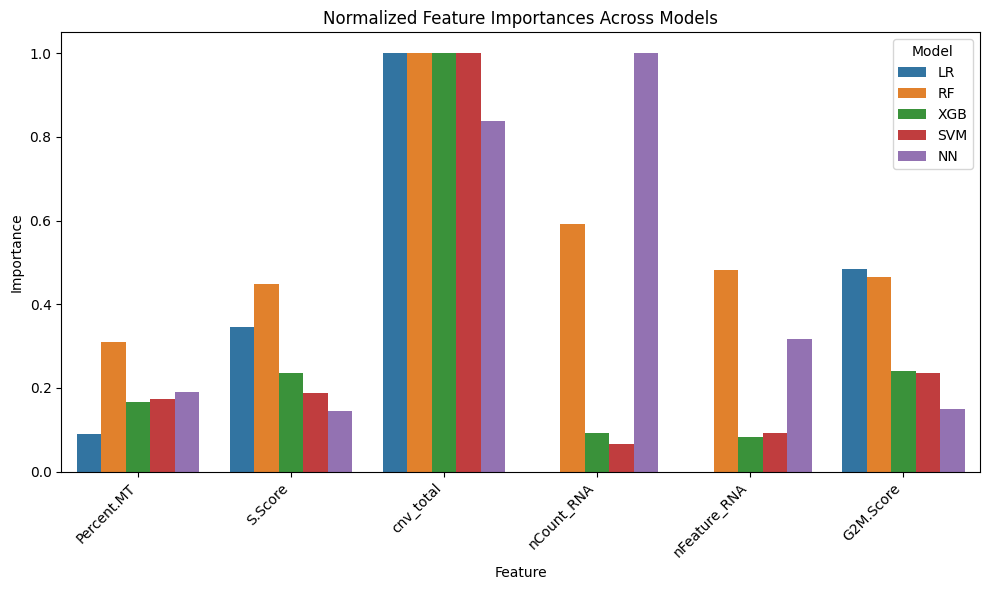

In [9]:

# Reset index to make 'Feature' a column
plot_df = normalized_df.reset_index().melt(
    id_vars='index',
    var_name='Model',
    value_name='Importance'
)

# Rename 'index' to 'Feature'
plot_df.rename(columns={'index': 'Feature'}, inplace=True)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, y='Importance', x='Feature', hue='Model')
plt.title("Normalized Feature Importances Across Models")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("/Users/debanjansaha/Desktop/pca_c_class_train_feature_import.pdf")




In [10]:
plot_df.to_csv("/Users/debanjansaha/Desktop/pca_c_feature_import.tsv", sep="\t", index=False)

###Run models on full training data and save to disk for later####

In [11]:
#Storing final models and scaling for full training dataset of cisplatin treated PC3 cells
scaler = StandardScaler()
pc3_c_X_full_scaled = scaler.fit_transform(pc3_c_X)

# Re-train final models on full dataset
final_models = {
    "LogisticRegression": LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, C=0.1),
    "RandomForest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
    "SVM": SVC(probability=True, kernel='rbf', C=1),  # RBF kernel, enable proba
    "NeuralNet": MLPClassifier(hidden_layer_sizes=(50, 20), max_iter=500)
}
#Fit all models on full X after scaling - save models to assess for generalizability 
for name in final_models:
    final_models[name].fit(pc3_c_X_full_scaled, pc3_c_y)



/opt/anaconda3/envs/ds/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [02:29:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


#Section 2: Validating with docetaxel-treated PC3 cells


In [12]:
#Testing on docetaxel treated PC3 cells from same publication
pc3_d_df = pd.read_csv("/Users/debanjansaha/Desktop/mCRPC_analysis/R/pc3_analysis/copykatres_pc3_d_meta.csv")  # must contain numeric features and 'label' column
pc3_d_df['label'] = pc3_d_df['Notation'].map({'d10': 1, 'd5': 1, 'PC3': 0})  # binary encoding
pc3_d_df = pc3_d_df.dropna()
pc3_d_X = pc3_d_df.drop(columns=['label', 'Unnamed: 0', 'cell', 'Notation'])
pc3_d_X = pc3_d_X[feature_cols]
pc3_d_y = pc3_d_df['label']

# Use scaling from full training set of X from cisplatin treated PC3 cells
pc3_d_X_scaled = scaler.transform(pc3_d_X)


# Predict for all models
for name, model in final_models.items():
    probs = model.predict_proba(pc3_d_X_scaled)[:, 1]
    pc3_d_df[f"{name}_WGD_prob"] = probs


In [13]:
from sklearn.metrics import roc_auc_score

#Calculated AUC scores for plotting on docetaxel treated PC3 cells
y_doc = pc3_d_df["label"]
for name in final_models:
    auc = roc_auc_score(y_doc, pc3_d_df[f"{name}_WGD_prob"])
    print(f"{name} AUC on Docetaxel: {auc:.3f}")


LogisticRegression AUC on Docetaxel: 0.970
RandomForest AUC on Docetaxel: 0.988
XGBoost AUC on Docetaxel: 0.986
SVM AUC on Docetaxel: 0.968
NeuralNet AUC on Docetaxel: 0.980


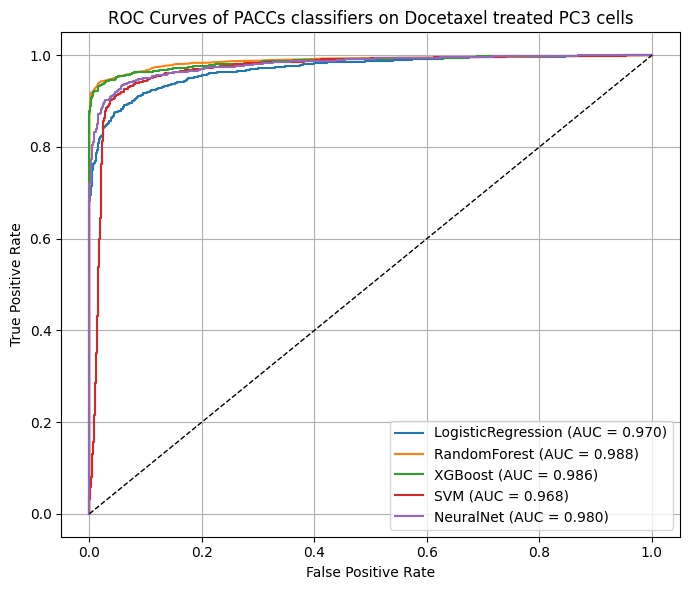

In [14]:
from sklearn.metrics import roc_curve, auc
#Plot ROC curves for each model on docetaxel treated PC3 dataset
plt.figure(figsize=(7, 6))

for name, model in final_models.items():
    y_pred_prob = model.predict_proba(pc3_d_X_scaled)[:, 1]
    # Append predicted probabilities to mda_df with a unique column name
    prob_col = f"{name}_prob"
    pc3_d_df[prob_col] = y_pred_prob
    fpr, tpr, _ = roc_curve(y_doc, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of PACCs classifiers on Docetaxel treated PC3 cells")
plt.legend()
plt.grid(True)
plt.tight_layout()


plt.savefig("/Users/debanjansaha/Desktop/pca_d_class_valid.pdf")


In [16]:
pc3_d_df.to_csv("/Users/debanjansaha/Desktop/pca_d_results.tsv", sep="\t", index=True)

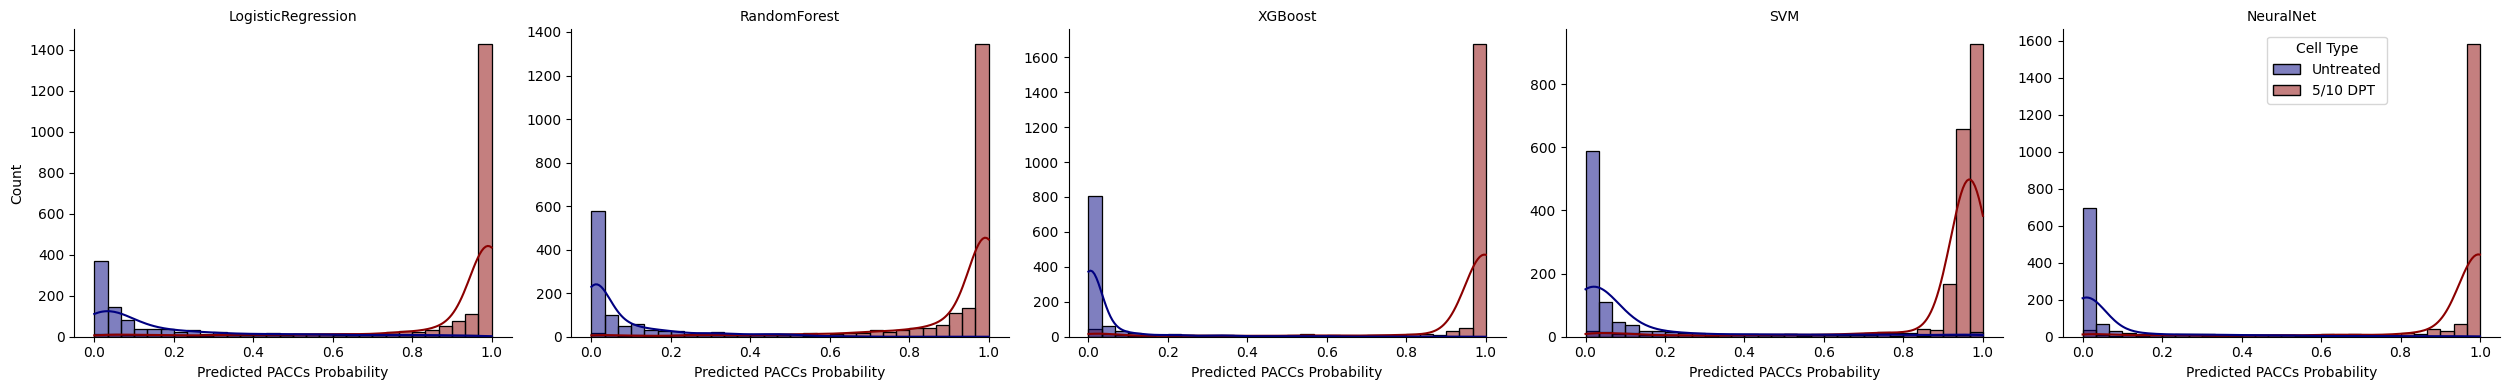

In [257]:
# Base classifiers used
classifiers = ["LogisticRegression", "RandomForest", "XGBoost", "SVM", "NeuralNet"]

# Columns for this threshold
prob_cols = [f"{clf}_prob" for clf in classifiers]

# Melt dataframe for plotting
melted = pc3_d_df.melt(
    id_vars="label",
    value_vars=prob_cols,
    var_name="Classifier",
    value_name="WGD_Prob"
)

# Clean classifier names
melted["Classifier"] = melted["Classifier"].str.replace(f"_prob", "", regex=False)
melted["label"] = melted["label"].map({0: "Untreated", 1: "5/10 DPT"})

# Plot
g = sns.displot(
    data=melted,
    x="WGD_Prob",
    hue="label",
    col="Classifier",
    bins=30,
    kde=True,
    facet_kws={'sharey': False, 'sharex': True},
    height=4,
    aspect=1.2,
    palette={"5/10 DPT": "darkred", "Untreated": "navy"}
)

g.set_titles("{col_name}")
g.set_axis_labels("Predicted PACCs Probability", "Count")
# Adjust legend placement
g._legend.set_title("Cell Type")   # optional: rename legend title
g._legend.set_bbox_to_anchor((0.95, 0.8))  # (x, y) anchor in figure coordinates
g._legend.set_frame_on(True)       # show legend box if desired

plt.tight_layout()
plt.savefig("/Users/debanjansaha/Desktop/plots/pca_d_class_postprob.pdf")
plt.show()



/var/folders/dd/2ggdq_bs7xz675sttlr0h0bm0000gn/T/ipykernel_10524/4073185579.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


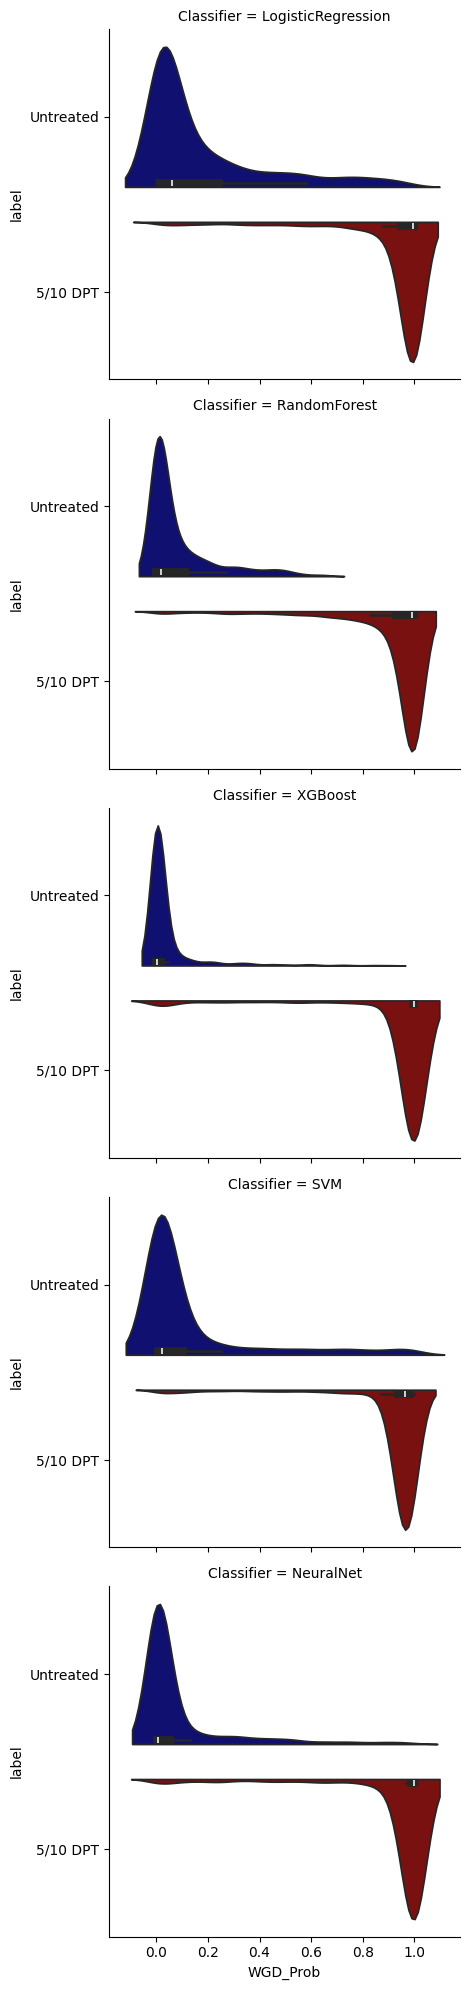

In [259]:
sns.catplot(
    data=melted,
    y="label",
    x="WGD_Prob",
    row="Classifier",
    kind="violin",
    split=True,        # PACCs vs Not PACCs in same violin
    palette={"5/10 DPT": "darkred", "Untreated": "navy"},
    height=4,
    aspect=1.2
)

plt.tight_layout()
plt.savefig("/Users/debanjansaha/Desktop/plots/pca_d_class_violin.pdf")
plt.show()



#Section 3: Validating on MDA treated cells


In [18]:
#Test on MDA cells treated with Docetaxel and Cisplatin for 5/10 days 
mda_c_df = pd.read_csv("/Users/debanjansaha/Desktop/mCRPC_analysis/R/mda_analysis/copykatres_mda_c_meta.csv") 
#Indicator if 10DPT for PACCs vs if untreated controls
mda_c_df['label'] = mda_c_df['Group'].map({'c5': 1, 'c10': 1, 'untreated': 0}) 
mda_c_df = mda_c_df.dropna()
mda_c_X = mda_c_df.drop(columns=['label', 'Unnamed: 0', 'cell', 'Group'])
mda_c_X = mda_c_X[feature_cols]
mda_c_y = mda_c_df['label']

# Use scaling from full training set of X from cisplatin treated PC3 cells
mda_c_X_scaled = scaler.transform(mda_c_X)


# Predict for all models
for name, model in final_models.items():
    probs = model.predict_proba(mda_c_X_scaled)[:, 1]
    mda_c_df[f"{name}_WGD_prob"] = probs

from sklearn.metrics import roc_auc_score

#Calculated AUC scores for plotting on docetaxel treated PC3 cells
y_mda = mda_c_df["label"]
for name in final_models:
    auc = roc_auc_score(y_mda, mda_c_df[f"{name}_WGD_prob"])
    print(f"{name} AUC on Docetaxel: {auc:.3f}")



LogisticRegression AUC on Docetaxel: 0.845
RandomForest AUC on Docetaxel: 0.828
XGBoost AUC on Docetaxel: 0.821
SVM AUC on Docetaxel: 0.809
NeuralNet AUC on Docetaxel: 0.838


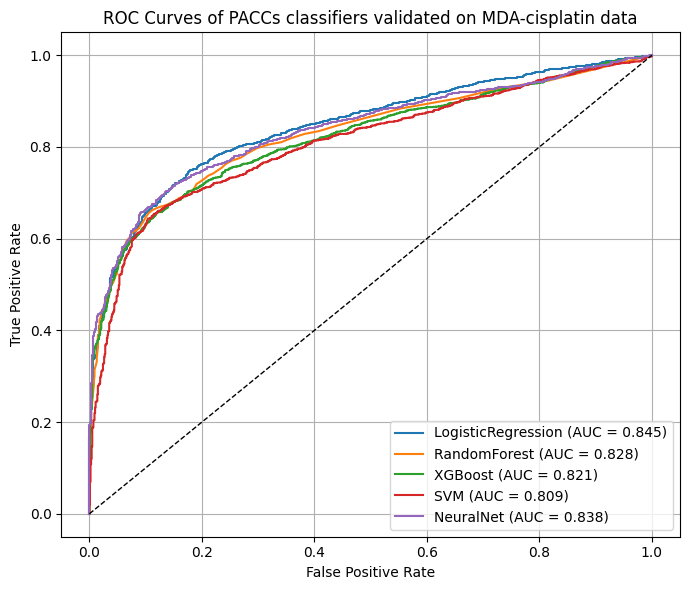

In [19]:
from sklearn.metrics import roc_curve, auc
#Plot ROC curves for each model on docetaxel treated PC3 dataset
plt.figure(figsize=(7, 6))

for name, model in final_models.items():
    y_pred_prob = model.predict_proba(mda_c_X_scaled)[:, 1]
    # Append predicted probabilities to mda_df with a unique column name
    prob_col = f"{name}_prob"
    mda_c_df[prob_col] = y_pred_prob
    fpr, tpr, _ = roc_curve(y_mda, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of PACCs classifiers validated on MDA-cisplatin data")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("/Users/debanjansaha/Desktop/mda_c_class_valid.pdf")



In [20]:
mda_c_df.to_csv("/Users/debanjansaha/Desktop/mda_c_results.tsv", sep="\t", index=True)

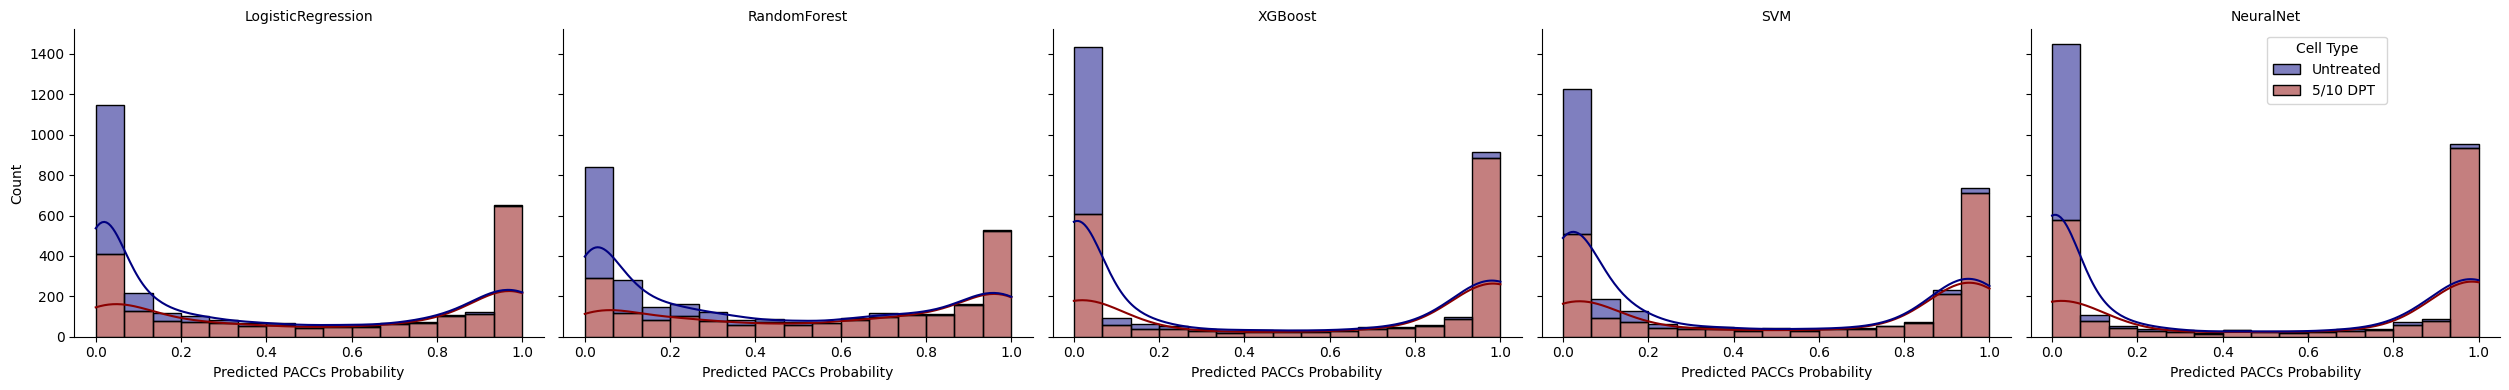

In [263]:
# Base classifiers used
classifiers = ["LogisticRegression", "RandomForest", "XGBoost", "SVM", "NeuralNet"]

# Columns for this threshold
prob_cols = [f"{clf}_prob" for clf in classifiers]

# Melt dataframe for plotting
melted = mda_c_df.melt(
    id_vars="label",
    value_vars=prob_cols,
    var_name="Classifier",
    value_name="WGD_Prob"
)

# Clean classifier names
melted["Classifier"] = melted["Classifier"].str.replace(f"_prob", "", regex=False)
melted["label"] = melted["label"].map({0: "Untreated", 1: "5/10 DPT"})

# Plot
g = sns.displot(
    data=melted,
    x="WGD_Prob",
    hue="label",
    col="Classifier",
    multiple= 'stack',
    kde=True,
    facet_kws={'sharey': True, 'sharex': True},
    height=4,
    aspect=1.2,
    palette={"5/10 DPT": "darkred", "Untreated": "navy"}
)

g.set_titles("{col_name}")
g.set_axis_labels("Predicted PACCs Probability", "Count")
# Adjust legend placement
g._legend.set_title("Cell Type")   # optional: rename legend title
g._legend.set_bbox_to_anchor((0.95, 0.8))  # (x, y) anchor in figure coordinates
g._legend.set_frame_on(True)       # show legend box if desired
plt.tight_layout()
plt.savefig("/Users/debanjansaha/Desktop/plots/mda_c_class_postprob.pdf")
plt.show()

/var/folders/dd/2ggdq_bs7xz675sttlr0h0bm0000gn/T/ipykernel_10524/2720936909.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


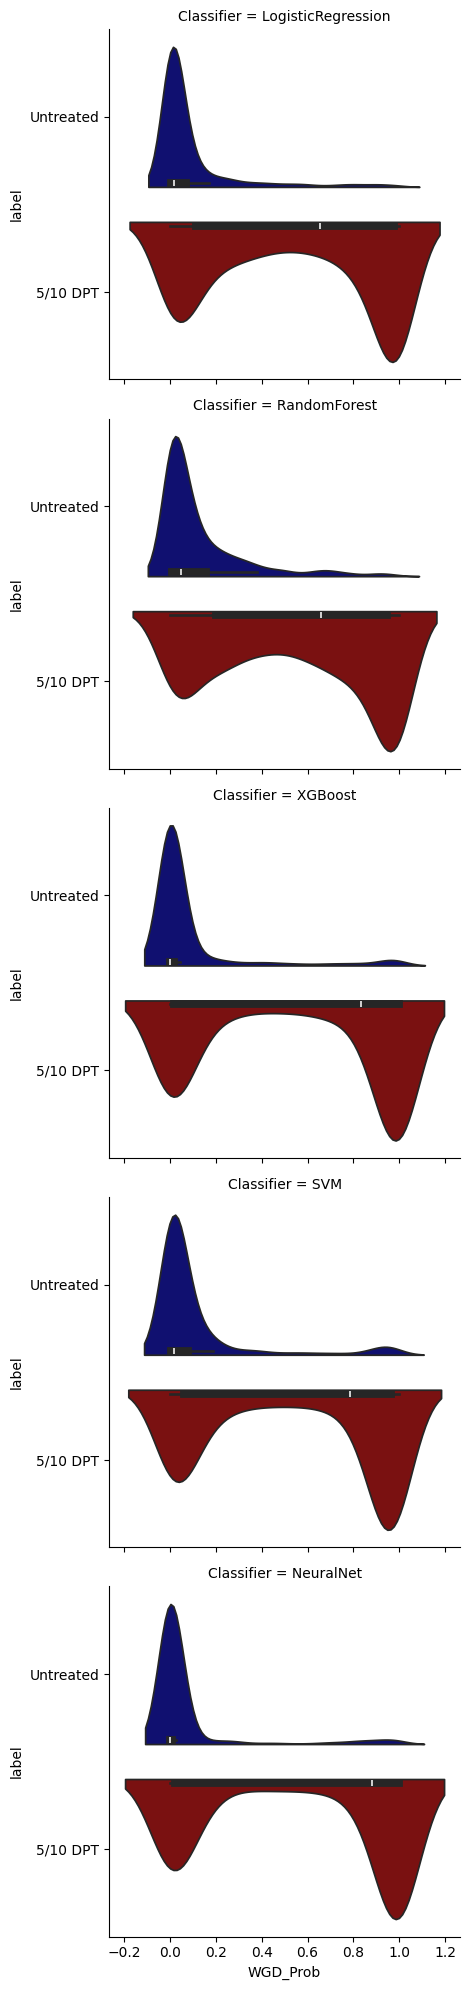

In [264]:
sns.catplot(
    data=melted,
    y="label",
    x="WGD_Prob",
    row="Classifier",
    kind="violin",
    split=True,        # PACCs vs Not PACCs in same violin
    palette={"5/10 DPT": "darkred", "Untreated": "navy"},
    height=4,
    aspect=1.2
)

plt.tight_layout()
plt.savefig("/Users/debanjansaha/Desktop/plots/mda_c_class_violin.pdf")
plt.show()

In [22]:
#Test on MDA cells treated with Docetaxel and Cisplatin for 5/10 days 
mda_d_df = pd.read_csv("/Users/debanjansaha/Desktop/mCRPC_analysis/R/mda_analysis/copykatres_mda_d_meta.csv") 
#Indicator if 10DPT for PACCs vs if untreated controls
mda_d_df['label'] = mda_d_df['Group'].map({'d5': 1, 'd10': 1, 'untreated': 0}) 
mda_d_df = mda_d_df.dropna()
mda_d_X = mda_d_df.drop(columns=['label', 'Unnamed: 0', 'cell',  'Group'])
mda_d_X = mda_d_X[feature_cols]
mda_d_y = mda_d_df['label']

# Use scaling from full training set of X from cisplatin treated PC3 cells
mda_d_X_scaled = scaler.transform(mda_d_X)


# Predict for all models
for name, model in final_models.items():
    probs = model.predict_proba(mda_d_X_scaled)[:, 1]
    mda_d_df[f"{name}_WGD_prob"] = probs

from sklearn.metrics import roc_auc_score

#Calculated AUC scores for plotting on docetaxel treated PC3 cells
y_mda = mda_d_df["label"]
for name in final_models:
    auc = roc_auc_score(y_mda, mda_d_df[f"{name}_WGD_prob"])
    print(f"{name} AUC on Docetaxel: {auc:.3f}")


LogisticRegression AUC on Docetaxel: 0.983
RandomForest AUC on Docetaxel: 0.976
XGBoost AUC on Docetaxel: 0.976
SVM AUC on Docetaxel: 0.969
NeuralNet AUC on Docetaxel: 0.982


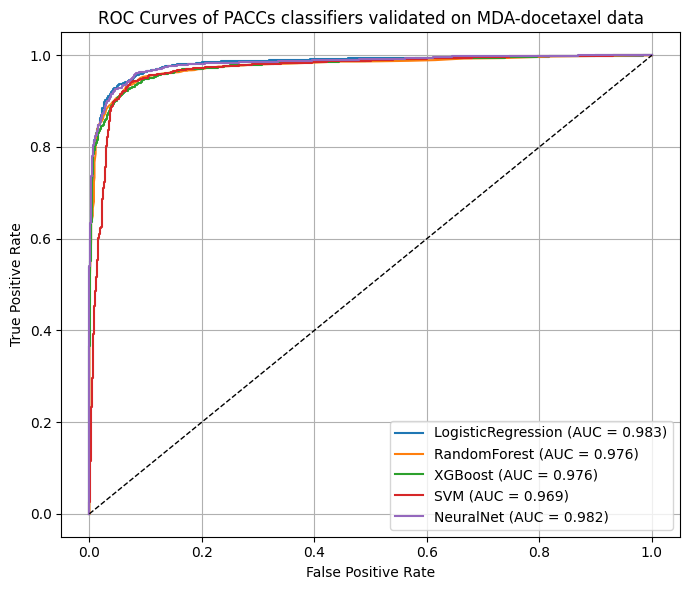

In [23]:
from sklearn.metrics import roc_curve, auc
#Plot ROC curves for each model on docetaxel treated PC3 dataset
plt.figure(figsize=(7, 6))

for name, model in final_models.items():
    y_pred_prob = model.predict_proba(mda_d_X_scaled)[:, 1]
    # Append predicted probabilities to mda_df with a unique column name
    prob_col = f"{name}_prob"
    mda_d_df[prob_col] = y_pred_prob
    fpr, tpr, _ = roc_curve(y_mda, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of PACCs classifiers validated on MDA-docetaxel data")
plt.legend()
plt.grid(True)
plt.tight_layout()


plt.savefig("/Users/debanjansaha/Desktop/mda_d_class_valid.pdf")


In [24]:
mda_d_df.to_csv("/Users/debanjansaha/Desktop/mda_d_results.tsv", sep="\t", index=True)

/var/folders/dd/2ggdq_bs7xz675sttlr0h0bm0000gn/T/ipykernel_10524/1859811471.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


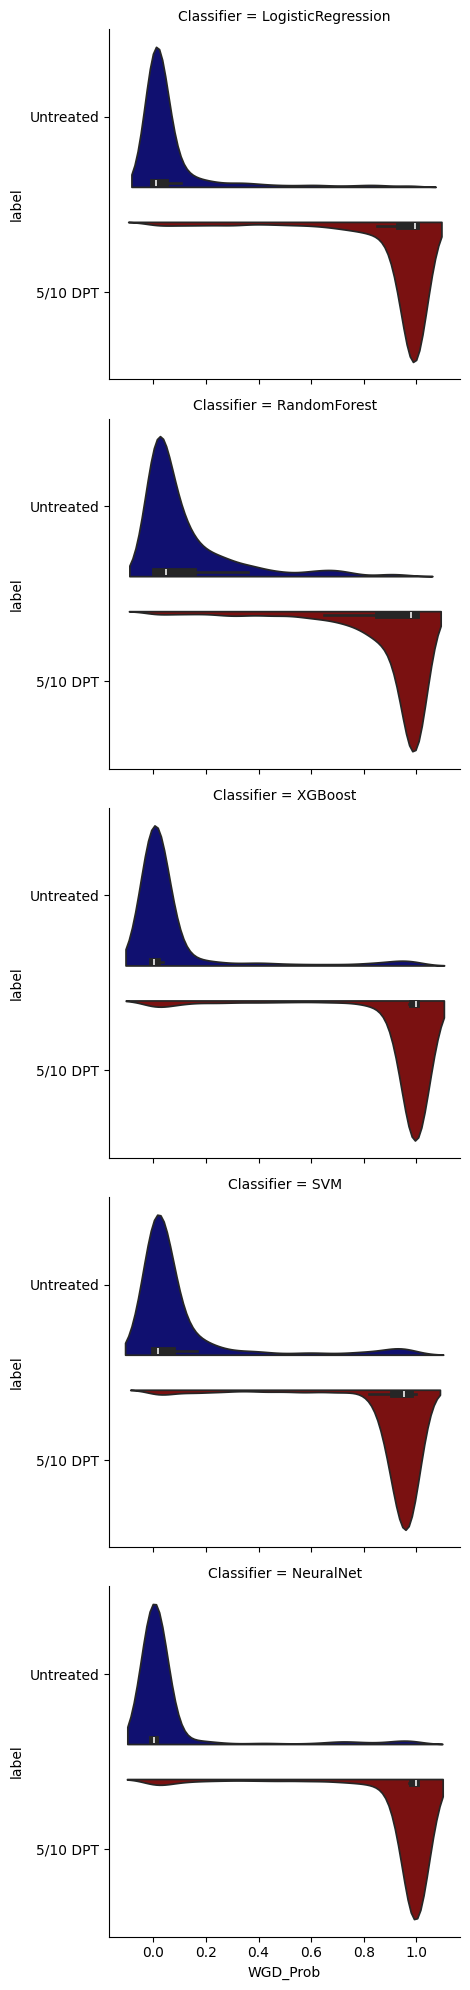

In [268]:
# Base classifiers used
classifiers = ["LogisticRegression", "RandomForest", "XGBoost", "SVM", "NeuralNet"]

# Columns for this threshold
prob_cols = [f"{clf}_prob" for clf in classifiers]

# Melt dataframe for plotting
melted = mda_d_df.melt(
    id_vars="label",
    value_vars=prob_cols,
    var_name="Classifier",
    value_name="WGD_Prob"
)

# Clean classifier names
melted["Classifier"] = melted["Classifier"].str.replace(f"_prob", "", regex=False)
melted["label"] = melted["label"].map({0: "Untreated", 1: "5/10 DPT"})


sns.catplot(
    data=melted,
    y="label",
    x="WGD_Prob",
    row="Classifier",
    kind="violin",
    split=True,        # PACCs vs Not PACCs in same violin
    palette={"5/10 DPT": "darkred", "Untreated": "navy"},
    height=4,
    aspect=1.2
)

plt.tight_layout()
plt.savefig("/Users/debanjansaha/Desktop/plots/mda_d_class_violin.pdf")
plt.show()

In [270]:
import joblib

# Save scaler and each model
joblib.dump(scaler, "/Users/debanjansaha/Desktop/mCRPC_analysis/results/paccs_classifiers_final_ver/scaler.pkl")
for name, model in final_models.items():
    joblib.dump(model, f"/Users/debanjansaha/Desktop/mCRPC_analysis/results/paccs_classifiers_final_ver/{name}.pkl")


#Resulting plots from Sensitivity analysis/repeated downsampling of MDA PACCs cells 

In [287]:
import os
import pandas as pd
from sklearn.metrics import roc_auc_score
import glob

# Set this to the folder where your predictions CSVs live
meta_dir = "/Users/debanjansaha/Desktop/mCRPC_analysis/R/sensitivity_analysis/"
meta_files = glob.glob(os.path.join(meta_dir, "mda_d_*_meta.csv"))

auc_records = []

for file in meta_files:
    df = pd.read_csv(file)

    sample_id = os.path.basename(file).replace("_meta.csv", "")
    print(f"Processing sample {sample_id}")

    # Create labels: PACCs (c5, c10) vs untreated
    df['label'] = df['Group'].map({'d5': 1, 'd10': 1, 'untreated': 0})
    df = df.dropna()
    y_true = df['label'].values  # Save y BEFORE dropping it from df

    # Extract features for prediction
    X = df[feature_cols]

    # Scale with training scaler
    X_scaled = scaler.transform(X)

    # Predict for all models
    for name, model in final_models.items():
        print(f"Rows: {X_scaled.shape[0]}, Columns: {X_scaled.shape[1]}")
        probs = model.predict_proba(X_scaled)[:, 1]

        # Compute AUC
        try:
            auc_val = roc_auc_score(y_true, probs)
            auc_records.append({
                "sample_id": sample_id,
                "model": name,
                "auc": auc_val
            })
            print(f"  {name} AUC: {auc_val:.3f}")
        except ValueError:
            print(f"  Skipping {name} in {sample_id}: only one class present")

# Collect all AUCs into one DataFrame
auc_df = pd.DataFrame(auc_records)

auc_df.to_csv("/Users/debanjansaha/Desktop/mCRPC_analysis/R/sensitivity_analysis/auc_mda_d.csv")

Processing sample mda_d_spk4000_ut1000_d11000_d510_d1010
Rows: 1013, Columns: 6
  LogisticRegression AUC: 0.995
Rows: 1013, Columns: 6
  RandomForest AUC: 0.996
Rows: 1013, Columns: 6
  XGBoost AUC: 0.996
Rows: 1013, Columns: 6
  SVM AUC: 0.978
Rows: 1013, Columns: 6
  NeuralNet AUC: 0.997
Processing sample mda_d_spk6000_ut3000_d13000_d510_d1010
Rows: 3008, Columns: 6
  LogisticRegression AUC: 0.992
Rows: 3008, Columns: 6
  RandomForest AUC: 0.994
Rows: 3008, Columns: 6
  XGBoost AUC: 0.993
Rows: 3008, Columns: 6
  SVM AUC: 0.978
Rows: 3008, Columns: 6
  NeuralNet AUC: 0.995
Processing sample mda_d_spk10000_ut5000_d15000_d510_d1010
Rows: 5000, Columns: 6
  LogisticRegression AUC: 0.992
Rows: 5000, Columns: 6
  RandomForest AUC: 0.994
Rows: 5000, Columns: 6
  XGBoost AUC: 0.993
Rows: 5000, Columns: 6
  SVM AUC: 0.977
Rows: 5000, Columns: 6
  NeuralNet AUC: 0.995
Processing sample mda_d_spk4000_ut1000_d11000_d5500_d10500
Rows: 1982, Columns: 6
  LogisticRegression AUC: 0.982
Rows: 1982, 

In [ ]:
import os
import pandas as pd
from sklearn.metrics import roc_auc_score
import glob

# Set this to the folder where your predictions CSVs live
meta_dir = "/Users/debanjansaha/Desktop/mCRPC_analysis/R/sensitivity_analysis/"
meta_files = glob.glob(os.path.join(meta_dir, "mda_c_*_meta.csv"))

auc_records = []

for file in meta_files:
    df = pd.read_csv(file)

    sample_id = os.path.basename(file).replace("_meta.csv", "")
    print(f"Processing sample {sample_id}")

    # Create labels: PACCs (c5, c10) vs untreated
    df['label'] = df['Group'].map({'c5': 1, 'c10': 1, 'untreated': 0})
    df = df.dropna()
    y_true = df['label'].values  # Save y BEFORE dropping it from df

    # Extract features for prediction
    X = df[feature_cols]

    # Scale with training scaler
    X_scaled = scaler.transform(X)

    # Predict for all models
    for name, model in final_models.items():
        print(f"Rows: {X_scaled.shape[0]}, Columns: {X_scaled.shape[1]}")
        probs = model.predict_proba(X_scaled)[:, 1]

        # Compute AUC
        try:
            auc_val = roc_auc_score(y_true, probs)
            auc_records.append({
                "sample_id": sample_id,
                "model": name,
                "auc": auc_val
            })
            print(f"  {name} AUC: {auc_val:.3f}")
        except ValueError:
            print(f"  Skipping {name} in {sample_id}: only one class present")

# Collect all AUCs into one DataFrame
auc_df = pd.DataFrame(auc_records)

auc_df.to_csv("/Users/debanjansaha/Desktop/mCRPC_analysis/R/sensitivity_analysis/auc_mda_c.csv")